In [ ]:
import tensorflow as tf
print(tf.__version__)

In [2]:
import sys
!"{sys.executable}" -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 7.8/7.8 MB 555.6 kB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 984.4 kB/s eta 0:00:00
     -------------------------------------- 211.8/211.8 KB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 KB 1.4 MB/s eta 0:00:00
     ------------------------------------ 122.8/122.8 KB 554.4 kB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'C:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


In [3]:
import tensorflow as tf 
import matplotlib.pyplot as plt 
from tensorflow import keras 
import numpy as np 

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 41s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


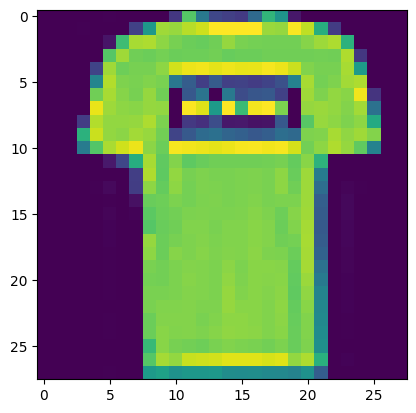

In [5]:
plt.imshow(x_train[1])
plt.show()

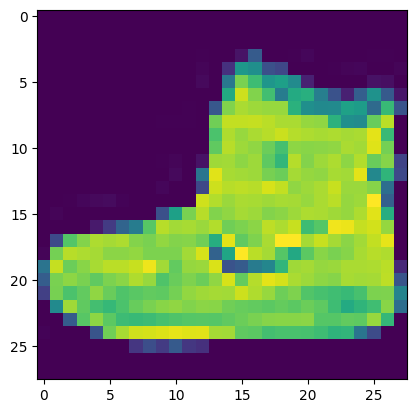

In [6]:
plt.imshow(x_train[0]) 

In [7]:
x_train = x_train.astype('float32') / 255.0 
x_test = x_test.astype('float32') / 255.0

In [8]:
x_train = x_train.reshape(-1, 28, 28, 1) 
x_test = x_test.reshape(-1, 28, 28, 1) 

In [9]:
x_train.shape

(60000, 28, 28, 1)

In [10]:
x_test.shape 

(10000, 28, 28, 1)

In [11]:
y_train.shape 

(60000,)

In [12]:
y_test.shape

(10000,)

In [17]:
model = keras.Sequential([
    keras.Input(shape=(28,28,1)),   # ✅ Add this

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), activation='relu'),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.25),

    keras.layers.Dense(10, activation='softmax')
])

In [18]:
model.summary() 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test)) 

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.7100 - loss: 0.7806 - val_accuracy: 0.8616 - val_loss: 0.3740
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 88s 42ms/step - accuracy: 0.8590 - loss: 0.3880 - val_accuracy: 0.8854 - val_loss: 0.3140
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.8793 - loss: 0.3283 - val_accuracy: 0.8916 - val_loss: 0.2977
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.8910 - loss: 0.2982 - val_accuracy: 0.8984 - val_loss: 0.2843
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.8992 - loss: 0.2737 - val_accuracy: 0.9027 - val_loss: 0.2682
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9022 - loss: 0.2616 - val_accuracy: 0.9002 - val_loss: 0.2658
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9076 - loss: 0.2539 - val_accuracy: 0.8937 - val_loss: 0.2847
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.9082 -

In [22]:
print('Test accuracy:', test_acc)

NameError: name 'test_acc' is not defined